In [1]:
import os
import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import numpy.random as nr
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import scipy
import pickle

cur_dir = os.getcwd()
path = Path(cur_dir)
sys.path.insert(0, str(path.parent.absolute()))

from src.safe_routing import*
from src.preprocess import preprocess_df
from src.network_connectivity import ConnectivityUnit

In [2]:
file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Tuesday-WorkingHours.pcap_ISCX.csv' 
df_cic = pd.read_csv(file_addr, header=0, encoding='cp1252')
df = preprocess_df(df_cic, date_col=' Timestamp')
df = df.iloc[:200_000]

In [3]:
df

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
133037,192.168.10.25-54.192.37.17-54988-443-6,54.192.37.17,443,192.168.10.25,54988,6,2017-04-07 01:00:00,54,1,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
394262,192.168.10.9-87.250.250.119-5303-443-6,87.250.250.119,443,192.168.10.9,5303,6,2017-04-07 01:00:00,101114,2,1,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
132995,192.168.10.25-52.84.145.136-54978-443-6,192.168.10.25,54978,52.84.145.136,443,6,2017-04-07 01:00:00,169399,22,30,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
132994,192.168.10.9-87.250.250.119-5260-443-6,192.168.10.9,5260,87.250.250.119,443,6,2017-04-07 01:00:00,148,2,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
138980,192.168.10.12-199.182.221.110-123-123-17,192.168.10.12,123,199.182.221.110,123,17,2017-04-07 01:00:00,71771,1,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266033,192.168.10.17-64.94.116.26-40949-80-6,192.168.10.17,40949,64.94.116.26,80,6,2017-04-07 04:39:00,116870729,71,95,...,32,142021.0909,191199.6645,718509.0,83965.0,10000000.0,22807.69714,10000000.0,9951993.0,BENIGN
266032,192.168.10.17-64.94.116.26-40950-80-6,192.168.10.17,40950,64.94.116.26,80,6,2017-04-07 04:39:00,116870217,166,308,...,32,186467.5455,338682.026,1207632.0,83999.0,10000000.0,7834.448964,10000000.0,10000000.0,BENIGN
410623,192.168.10.3-192.168.10.5-53-63994-17,192.168.10.5,63994,192.168.10.3,53,17,2017-04-07 04:39:00,110565,4,2,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
266031,192.168.10.17-38.69.238.17-55308-80-6,192.168.10.17,55308,38.69.238.17,80,6,2017-04-07 04:39:00,115518948,20,19,...,32,73229.09091,136574.0049,485015.0,31905.0,10000000.0,6283.803391,10000000.0,9997747.0,BENIGN


In [4]:
with open(r'saves\victim_net.pickle', 'rb') as handle:
   entity_names = pickle.load(handle) 

In [4]:
with open(r'saves\partitioned_nodes_141.pickle', 'rb') as handle:
   entity_names = pickle.load(handle) 

In [21]:
with open(r'saves\monday_759.pickle', 'rb') as handle:
   entity_names = pickle.load(handle) 

In [5]:
import src.network_plotting, importlib

importlib.reload(src.safe_routing)
from src.safe_routing import*

In [6]:
g = communication_graph_from_df(df, entity_names, keep_outsiders=False, spanning_tree=True)
entity_names = list(g.nodes)
len(g), len(entity_names)

(95, 95)

In [7]:
cu = ConnectivityUnit()
cu.read_flows(df, conn_param='NPR', entity_names=entity_names,
             window_type= 'time', sync_window_size= 1.2, time_scale= 'sec')

cu.fit_connectivity_model(method = 'cov') # cov


Conditioning number:  1575465605203567.0 
Determinant of F^T*F:  -1.999328156391656e-22


In [25]:
cu.fit_connectivity_model(method = 'cov') # cov

Conditioning number:  2626732847596747.0 
Determinant of F^T*F:  -4.001913555977009e-18


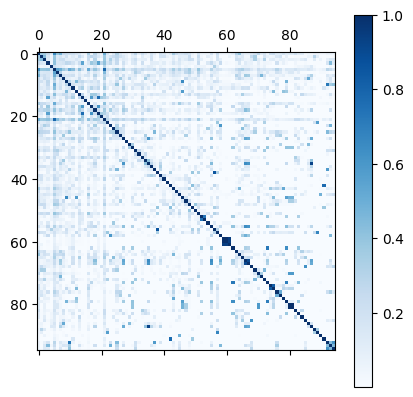

In [10]:
plt.matshow(cu.mat_f, cmap='Blues')
plt.colorbar()

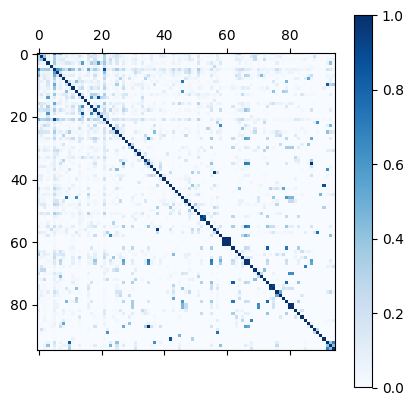

In [12]:
mat_f = cu.suppress_f(degree= 2, inplace=False)
plt.matshow(mat_f, cmap='Blues')
plt.colorbar()

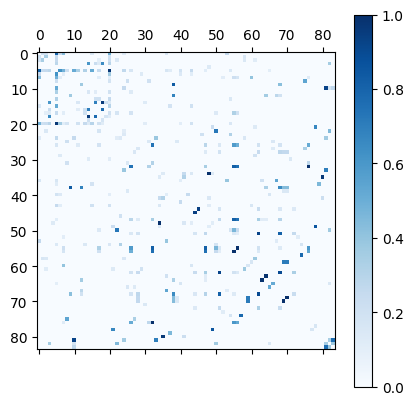

In [13]:
# Cleanup mat_f
cu.suppress_f(degree= 2)
mat_f = cu.clip_f(0.1, inplace=False)

g_f = nx.from_numpy_array(mat_f - np.diag(np.diag(mat_f)))
nx.relabel_nodes(g_f, {i:name for i, name in enumerate(entity_names)}, copy=False)
gcc = sorted(nx.connected_components(g_f), key=len, reverse=True)
g_f = g_f.subgraph(gcc[0])
mat_f = nx.to_numpy_array(g_f)
entity_names = list(g_f.nodes)

plt.matshow(mat_f, cmap='Blues')
plt.colorbar()

#g_f = nx.from_numpy_array(mat_f - np.diag(np.diag(mat_f)))
#nx.relabel_nodes(g_f, {i:name for i, name in enumerate(entity_names)}, copy=False)
#entity_names = sublist[0].names

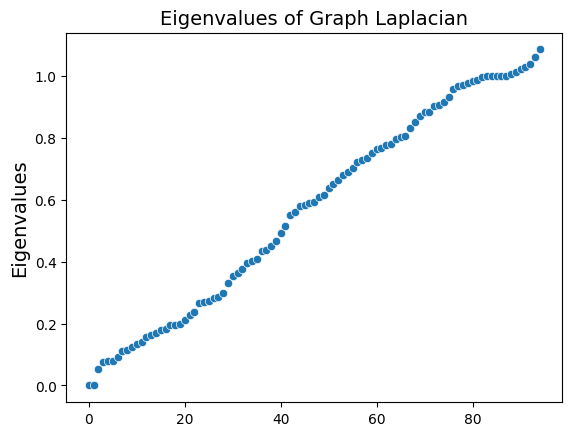

0.9936210363469414
[-3.94649591e-17  5.38332811e-04  5.24606268e-02  7.65794353e-02
  7.85946908e-02  7.93127504e-02  9.29998178e-02  1.12152808e-01
  1.14640794e-01  1.25364717e-01]


In [15]:
from src.network_partitioning import get_eig_vals_err

eigvals, err = get_eig_vals_err(cu.mat_f, cu.names)

print(err)
print(eigvals[:10])

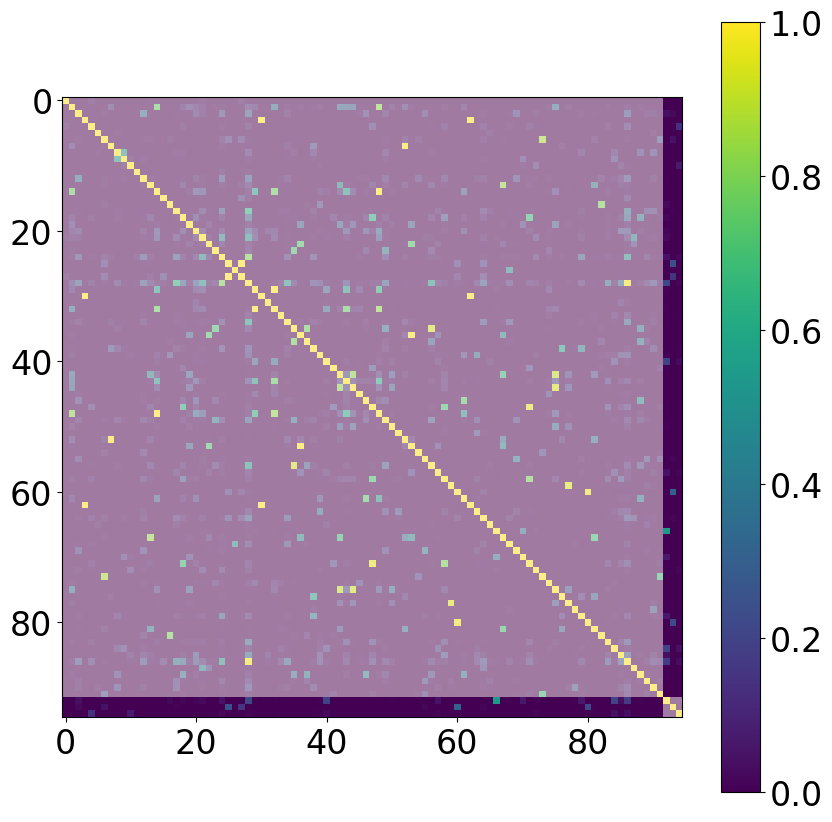

In [17]:
from src.network_connectivity import apply_partitioning

apply_partitioning(cu, 2, plot_bool=True)

In [19]:
import src.network_connectivity, importlib

importlib.reload(src.network_connectivity)
from src.network_connectivity import*

In [18]:
from src.analyze_cic_ids import get_risk_mat_from_df

risk_mat, labels, labels_count, _, _, all_cov = get_risk_mat_from_df(df, entity_names=entity_names, t_graph=90, sync_window_size=1.2,
                                                                    return_cov=True)
risk_mean, risk_cov = risk_mat[-1,:], all_cov[-1]

with open(r'saves\layout_medium2.pickle', 'wb') as handle: # sample_nodes.pickle
    pickle.dump((risk_mean, risk_cov, mat_f, g), handle, protocol=pickle.HIGHEST_PROTOCOL)


1
Current time and samples shape:  2017-04-07 01:02:00 (75, 84)
2
Current time and samples shape:  2017-04-07 01:04:00 (75, 84)
3
Current time and samples shape:  2017-04-07 01:06:00 (75, 84)
4
Current time and samples shape:  2017-04-07 01:08:00 (75, 84)
5
Current time and samples shape:  2017-04-07 01:10:00 (75, 84)
6
Current time and samples shape:  2017-04-07 01:12:00 (75, 84)
7
Current time and samples shape:  2017-04-07 01:14:00 (75, 84)
8
Current time and samples shape:  2017-04-07 01:16:00 (75, 84)
9
Current time and samples shape:  2017-04-07 01:18:00 (75, 84)
10
Current time and samples shape:  2017-04-07 01:20:00 (75, 84)
11
Current time and samples shape:  2017-04-07 01:22:00 (75, 84)
12
Current time and samples shape:  2017-04-07 01:24:00 (75, 84)
13
Current time and samples shape:  2017-04-07 01:26:00 (75, 84)
14
Current time and samples shape:  2017-04-07 01:28:00 (75, 84)
15
Current time and samples shape:  2017-04-07 01:30:00 (75, 84)
16
Current time and samples shape:

In [20]:
min(risk_mean)

2.69046741933158e-26

In [28]:
with open(r'saves\layout_medium2.pickle', 'rb') as handle:
    risk_mean, risk_cov, mat_f, g = pickle.load(handle) 

g_f = nx.from_numpy_array(mat_f - np.diag(np.diag(mat_f)))
nx.relabel_nodes(g_f, {i:name for i, name in enumerate(entity_names)}, copy=False)

In [60]:
import src.network_plotting, importlib

importlib.reload(src.network_plotting)
from src.network_plotting import*

In [24]:
len(g_f), len(risk_mean), len(entity_names)

(84, 84, 84)

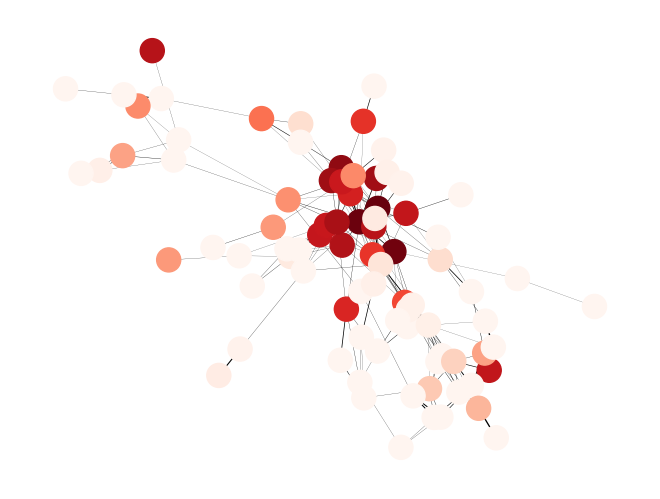

In [25]:
widths = [g_f[u][v]['weight'] for u,v in g_f.edges]
pos_f = risk_elevation_layout(g_f, risks=risk_mean, alpha=2, seed=28, iterations=500)
# pos_f = nx.spring_layout(g_f, seed=28, iterations=500)
nx.draw(g_f, pos=pos_f, width=widths, node_color=risk_mean, cmap='Reds', with_labels=False)

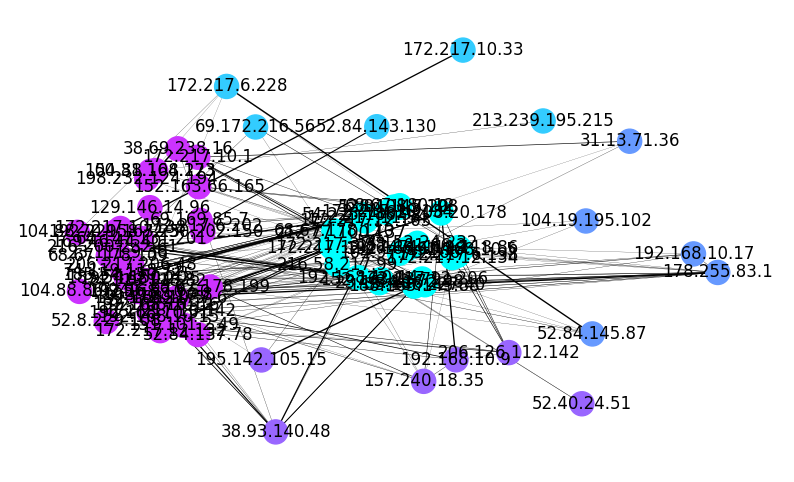

In [62]:
d_xy, d_z = 1.3, 2
n_cluster = 5
pos_pie, risk_mean, risk_cov, node_colors, r, gt = pie_layout(mat_f, entity_names, n_cluster, risk_mean=risk_mean,
                                                   risk_cov=risk_cov, d_xy=d_xy, d_z=d_z, r_const=2.5, alpha=2,
                                                   plot_bool=True, with_labels=True)

In [34]:
min(risk_mean)

2.0593216405285874e-25

C:\Users\bayer\PycharmProjects\NRE\venv2\lib\site-packages\networkx\drawing\nx_pylab.py:433: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


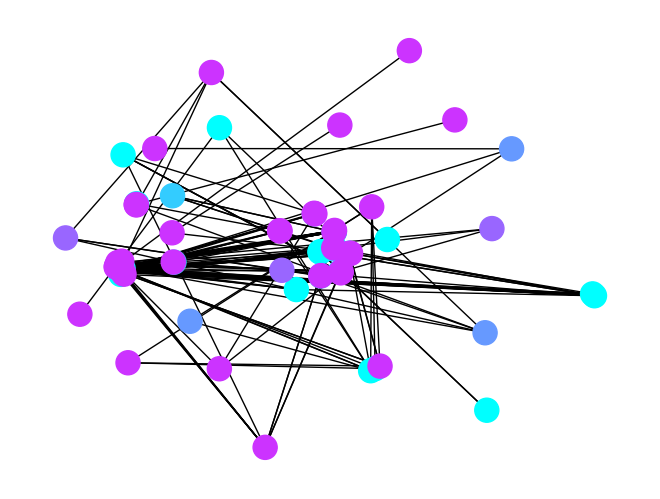

In [61]:
temp_colors = [clr[:3] for name, clr in zip(entity_names, node_colors)]
nx.draw(g_f, pos=pos_pie, cmap='Reds', node_color=temp_colors, with_labels=False)

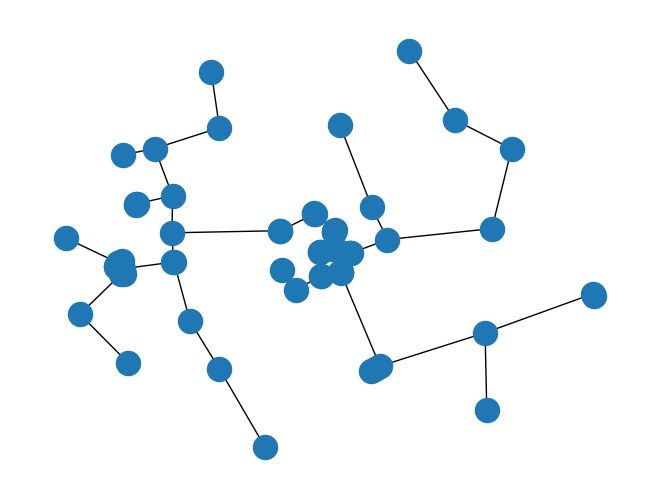

In [36]:
g_skeletal = get_layout_tree(g_f, pos_pie)
nx.draw(g_skeletal, pos=pos_pie, cmap='Reds', with_labels=False)

In [39]:
pos_dict = {name: pos_pie[name].tolist() for name in pos_pie}
edges_list = list(g_skeletal.edges)
risk_mean_dict = {name: val.tolist() for name, val in zip(gt.nodes, risk_mean)}
risk_cov_list = risk_cov.tolist()
g_f_adj = nx.adjacency_matrix(gt).todense().tolist()
color_dict = {name: color for name, color in zip(gt.nodes, node_colors)}
extras = {'n_cluster': n_cluster, 'diam_xy': d_xy, 'diam_z': d_z, 'radius': r}

In [73]:
pos2json(r"../src/network_rendering/saves/net_data_medium2", pos = pos_dict, topologyEdges=edges_list, risk_mean=risk_mean_dict,
         risk_cov = risk_cov_list, funcEdges=g_f_adj, entityColors=color_dict, extras=extras)